# Prescriptive 4th Down Model — EPA-Based Recommendation
**Goal:** For each 4th down situation, determine which play type (go-for-it, punt, field goal) maximizes expected EPA, then train a classifier to recommend the optimal decision from pre-snap features.

**Pipeline:**
1. Load & filter data
2. Engineer the prescriptive target (optimal play type by EPA)
3. Select pre-snap features
4. Train/test split (season-based to avoid leakage)
5. Baseline logistic regression
6. Random forest / XGBoost
7. Evaluate & compare

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    log_loss, ConfusionMatrixDisplay
)
from sklearn.model_selection import cross_val_score
import xgboost as xgb
import warnings
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint, uniform, loguniform
import time
from sklearn.preprocessing import LabelEncoder
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
print('Libraries loaded.')

Libraries loaded.


## 1. Load Data

In [4]:
df = pd.read_csv('../encoded_fourth_downs.csv.gz', low_memory=False, compression='gzip')

print(f'Raw rows: {len(df):,}')
print(f'Seasons: {sorted(df["season"].unique())}')
df.head(2)

Raw rows: 38,762
Seasons: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


,is_fourth_down,is_hard_count,week,yardline_100,quarter_seconds_remaining,half_seconds_remaining,game_seconds_remaining,drive,sp,qtr,down,goal_to_go,ydstogo,ydsnet,yards_gained,shotgun,no_huddle,qb_dropback,qb_scramble,air_yards,yards_after_catch,kick_distance,home_timeouts_remaining,away_timeouts_remaining,posteam_timeouts_remaining,...,playcaller_Nathaniel Hackett,playcaller_Nick Sirianni,playcaller_Norv Turner,playcaller_Parks Frazier,playcaller_Pat Shurmur,playcaller_Pep Hamilton,playcaller_Pete Carmichael,playcaller_Press Taylor,playcaller_Randy Fichtner,playcaller_Rich Scangarello,playcaller_Ryan Grubb,playcaller_Scott Linehan,playcaller_Scott Milanovich,playcaller_Scott Turner,playcaller_Sean Payton,playcaller_Shane Steichen,playcaller_Shane Waldron,playcaller_Steve Sarkisian,playcaller_Thomas Brown,playcaller_Tim Kelly,playcaller_Todd Downing,playcaller_Todd Haley,playcaller_Todd Monken,playcaller_Zac Robinson,playcaller_Zac Taylor
0,0,1,11,60.0,826,1726,3526,0,0,0,0,0,1,9,0.0,0,0,1.0,0,13.0,0.0,0.0,3,2,2.0,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,0,1,5,72.0,814,1714,3514,0,0,0,0,0,7,9,6.0,1,0,1.0,0,6.0,0.0,0.0,3,2,2.0,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


## 2. Filter to True 4th Down Decision Plays

We only want plays where a real decision was made: go-for-it, punt, or field goal attempt. Hard counts and no-plays are excluded from training since no outcome EPA exists.

In [5]:
# Map play types to the three decision categories
play_type_map = {
    'run': 'go',
    'pass': 'go',
    'punt': 'punt',
    'field_goal': 'field_goal'
#    'hard_count': 'hard_count' # removing hard count because it pollutes the other buckets. totally different interpretation
}

# Identify play_type column — adjust name if yours differs
# The encoded version splits into dummies; reconstruct if needed
play_type_cols = [c for c in df.columns if c.startswith('play_type_') 
                  and c in ['play_type_pass', 'play_type_run', 'play_type_punt']]
# append 'is_hard_count' if it exists
if 'is_hard_count' in df.columns:
    play_type_cols.append('is_hard_count')

# If play_type is already a raw string column, use it directly
if 'play_type' in df.columns:
    df['decision'] = df['play_type'].map(play_type_map)
else:
    # Reconstruct from dummies
    def get_decision(row):
    #    if row.get('is_hard_count', 0) == 1:
    #        return 'hard_count'
        if row.get('play_type_pass', 0) == 1 or row.get('play_type_run', 0) == 1:
            return 'go'
        elif row.get('play_type_punt', 0) == 1:
            return 'punt'
        elif row.get('field_goal_attempt', 0) == 1:
            return 'field_goal'
        else:
            return np.nan
    df['decision'] = df.apply(get_decision, axis=1)

# Drop rows without a clear decision or missing EPA
df_clean = df.dropna(subset=['decision', 'epa']).copy()
df_clean = df_clean[df_clean['decision'].isin(['go', 'punt', 'field_goal'])]

# Exclude hard counts (no real play ran)
#if 'is_hard_count' in df_clean.columns:
#    df_clean = df_clean[df_clean['is_hard_count'] != 1]

print(f'Usable 4th down plays: {len(df_clean):,}')
print(df_clean['decision'].value_counts())

Usable 4th down plays: 34,897
decision
punt          19488
field_goal     8571
go             6838
Name: count, dtype: int64


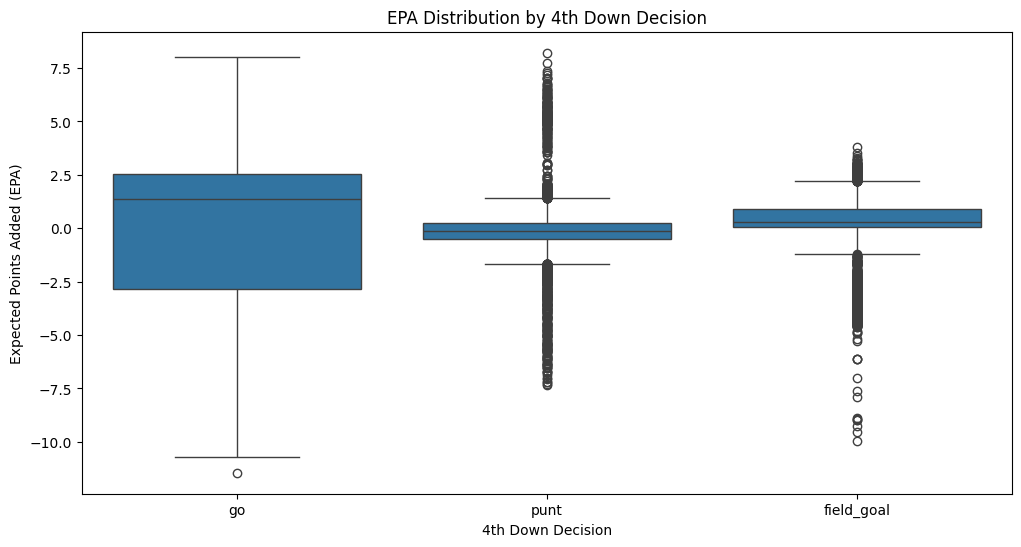

In [6]:
# Investigate epa column for different decisions
plt.figure(figsize=(12, 6))
sns.boxplot(x='decision', y='epa', data=df_clean)
plt.title('EPA Distribution by 4th Down Decision')
plt.xlabel('4th Down Decision')
plt.ylabel('Expected Points Added (EPA)')
plt.show()

## 3. Build the Prescriptive Target

**Logic:** Group plays into situational buckets (yard line × yards-to-go × score differential bin × season era). Within each bucket, compute the mean EPA for each decision type. The optimal decision for that bucket is whichever has the highest mean EPA. Assign that as the target label for every play in the bucket.

This is the 'naive' prescriptive approach your professor described — it uses realized EPA averages as a proxy for expected value.

In [7]:
# Bin continuous situational variables into buckets
df_clean['ydstogo_bin'] = pd.cut(df_clean['ydstogo'], bins=[0, 1, 3, 6, 10, 99], 
                                  labels=['1', '2-3', '4-6', '7-10', '10+'])
df_clean['yardline_bin'] = pd.cut(df_clean['yardline_100'], bins=[0, 20, 40, 60, 80, 100],
                                   labels=['opp_red_zone', 'opp_40', 'midfield', 'own_40', 'own_end'])
df_clean['score_diff_bin'] = pd.cut(df_clean['score_differential'], 
                                     bins=[-100, -14, -7, -3, 3, 7, 14, 100],
                                     labels=['down_14+', 'down_8-14', 'down_1-7', 
                                             'close', 'up_1-7', 'up_8-14', 'up_14+'])

# Era indicator for kickoff rule change
df_clean['kickoff_era'] = df_clean['season'].apply(
    lambda s: 'dynamic' if s >= 2023 else 'traditional'
)

# Group key
group_cols = ['ydstogo_bin', 'yardline_bin', 'score_diff_bin', 'kickoff_era']

# Mean EPA per decision type within each situational bucket
epa_by_situation = (
    df_clean
    .groupby(group_cols + ['decision'])['epa']
    .mean()
    .reset_index()
    .rename(columns={'epa': 'mean_epa'})
)

# Pivot so each row is a situation with one column per decision type
epa_pivot = epa_by_situation.pivot_table(
    index=group_cols, columns='decision', values='mean_epa'
).reset_index()
epa_pivot.columns.name = None

# Fill missing decision types with NaN (bucket had no plays of that type)
for col in ['go', 'punt', 'field_goal']:
    if col not in epa_pivot.columns:
        epa_pivot[col] = np.nan

# Optimal decision = whichever decision has highest mean EPA in that bucket
epa_pivot['optimal_decision'] = epa_pivot[['go', 'punt', 'field_goal']].idxmax(axis=1)

print(f'Unique situational buckets: {len(epa_pivot):,}')
print(epa_pivot['optimal_decision'].value_counts())
epa_pivot.head(20)

Unique situational buckets: 350
optimal_decision
go            134
punt          113
field_goal    103
Name: count, dtype: int64


,ydstogo_bin,yardline_bin,score_diff_bin,kickoff_era,field_goal,go,punt,optimal_decision
0,1,opp_red_zone,down_14+,dynamic,NaN,0.541353,NaN,go
1,1,opp_red_zone,down_14+,traditional,0.218074,-0.483288,NaN,field_goal
2,1,opp_red_zone,down_8-14,dynamic,0.104501,0.692004,NaN,go
3,1,opp_red_zone,down_8-14,traditional,-0.045676,-0.343601,NaN,field_goal
4,1,opp_red_zone,down_1-7,dynamic,0.197110,-0.215262,NaN,field_goal
5,1,opp_red_zone,down_1-7,traditional,0.125031,-0.708669,NaN,field_goal
6,1,opp_red_zone,close,dynamic,0.025380,-0.392689,NaN,field_goal
7,1,opp_red_zone,close,traditional,-0.187967,-0.294438,NaN,field_goal
8,1,opp_red_zone,up_1-7,dynamic,-0.801081,-0.215653,NaN,go
9,1,opp_red_zone,up_1-7,traditional,0.161594,-0.793150,NaN,field_goal


In [8]:
# Merge optimal_decision back onto the play-level data
df_model = df_clean.merge(epa_pivot[group_cols + ['optimal_decision']], 
                           on=group_cols, how='left')

# Drop rows where optimal_decision couldn't be determined (sparse buckets)
df_model = df_model.dropna(subset=['optimal_decision'])

print(f'Model-ready rows: {len(df_model):,}')
print(df_model['optimal_decision'].value_counts())

Model-ready rows: 34,897
optimal_decision
go            13121
punt          11266
field_goal    10510
Name: count, dtype: int64


### Quick sanity check: does the optimal decision make intuitive sense?

In [9]:
# Show optimal decisions by yardline and distance bins
sanity = epa_pivot.groupby(['yardline_bin', 'ydstogo_bin'])['optimal_decision'] \
    .agg(lambda x: x.value_counts().index[0]).unstack()

print('Most common optimal decision by field position & distance:')
print(sanity.to_string())

Most common optimal decision by field position & distance:
ydstogo_bin            1   2-3         4-6        7-10         10+
yardline_bin                                                      
opp_red_zone  field_goal    go  field_goal  field_goal  field_goal
opp_40                go    go  field_goal  field_goal  field_goal
midfield              go    go          go          go        punt
own_40                go    go        punt        punt        punt
own_end             punt  punt        punt        punt        punt


## 4. Feature Selection (Pre-Snap Only)

We use only features a coach would know *before* the snap. Post-play outcomes (yards_gained, epa, fourth_down_converted, etc.) are excluded to prevent leakage.

In [10]:
# Core situational features
pre_snap_features = [
    'yardline_100',        # field position (yards from end zone)
    'ydstogo',             # yards needed for first down
    'score_differential',  # score diff (positive = winning)
    'game_seconds_remaining',
    'half_seconds_remaining',
    'qtr',
    'posteam_timeouts_remaining',
    'defteam_timeouts_remaining',
    'goal_to_go',
    'shotgun',
    'no_huddle',
    'home_is_posteam',     # home/away context
]

# EPA-based pregame context (these are pre-game, not post-play)
pregame_epa_features = [
    'no_score_prob', 'opp_fg_prob', 'opp_td_prob',
    'fg_prob', 'td_prob',   # pre-snap win probability components
]

# Kickoff era indicator
era_features = ['kickoff_era']

# Playcaller dummies (coaching tendency)
playcaller_cols = [c for c in df_model.columns if c.startswith('playcaller_')]

# Season fixed effects
df_model['season_fixed'] = df_model['season'].astype(str)

all_features = pre_snap_features + pregame_epa_features + playcaller_cols

# Encode era as binary
df_model['is_dynamic_era'] = (df_model['kickoff_era'] == 'dynamic').astype(int)
all_features.append('is_dynamic_era')

# Season dummies
season_dummies = pd.get_dummies(df_model['season'], prefix='season', drop_first=True)
df_model = pd.concat([df_model, season_dummies], axis=1)
all_features += list(season_dummies.columns)

# Keep only features actually present in the dataframe
all_features = [f for f in all_features if f in df_model.columns]

print(f'Total features: {len(all_features)}')
print(all_features)

Total features: 113
['yardline_100', 'ydstogo', 'score_differential', 'game_seconds_remaining', 'half_seconds_remaining', 'qtr', 'posteam_timeouts_remaining', 'defteam_timeouts_remaining', 'goal_to_go', 'shotgun', 'no_huddle', 'home_is_posteam', 'no_score_prob', 'opp_fg_prob', 'opp_td_prob', 'fg_prob', 'td_prob', 'playcaller_Alex Van Pelt', 'playcaller_Andy Reid', 'playcaller_Anthony Lynn', 'playcaller_Arthur Smith', 'playcaller_Ben Johnson', 'playcaller_Ben McAdoo', 'playcaller_Bill Lazor', 'playcaller_Bill Musgrave', "playcaller_Bill O'Brien", 'playcaller_Bo Hardegree', 'playcaller_Bobby Slowik', 'playcaller_Brian Callahan', 'playcaller_Brian Daboll', 'playcaller_Brian Johnson', 'playcaller_Brian Schottenheimer', 'playcaller_Byron Leftwich', "playcaller_Chad O'Shea", 'playcaller_Chan Gailey', 'playcaller_Darrell Bevell', 'playcaller_Dave Canales', 'playcaller_Dave Ragone', 'playcaller_Dirk Koetter', 'playcaller_Doug Pederson', 'playcaller_Dowell Loggains', 'playcaller_Drew Petzing', 

In [11]:
# Build X and y, drop rows with any NaN in features
X = df_model[all_features].copy()
y = df_model['optimal_decision'].copy()

# Convert boolean columns to int
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)

# Drop rows with missing feature values
mask = X.notna().all(axis=1)
X, y = X[mask], y[mask]

print(f'Final dataset: {len(X):,} plays')
print(f'Class distribution:\n{y.value_counts()}')

Final dataset: 34,897 plays
Class distribution:
optimal_decision
go            13121
punt          11266
field_goal    10510
Name: count, dtype: int64


## 5. Train/Test Split — Season-Based

We use seasons 2019–2023 for training and 2024 for testing. This mirrors real-world usage (train on history, predict current season) and avoids temporal leakage.

In [12]:
TEST_SEASON = 2024

season_col = df_model.loc[mask, 'season']

train_idx = season_col[season_col < TEST_SEASON].index
test_idx  = season_col[season_col == TEST_SEASON].index

X_train, X_test = X.loc[train_idx], X.loc[test_idx]
y_train, y_test = y.loc[train_idx], y.loc[test_idx]

print(f'Train: {len(X_train):,} plays  |  Test: {len(X_test):,} plays')
print(f'Train seasons: {sorted(season_col[train_idx].unique())}')
print(f'Test season:   {sorted(season_col[test_idx].unique())}')

Train: 26,351 plays  |  Test: 4,556 plays
Train seasons: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
Test season:   [np.int64(2024)]


## 6. Model Training

### 6a. Baseline — Multinomial Logistic Regression

In [13]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, uniform
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import make_scorer, log_loss

def tune_logistic_regression(X_train, y_train, X_test, y_test, n_iter=30, cv_folds=5, verbose=True):

    param_dist = {
        'clf__C':        loguniform(0.001, 100),   # log-uniform sample between 0.001 and 100
        'clf__penalty':  ['l1', 'l2', 'elasticnet'],
        'clf__solver':   ['saga'],
        'clf__l1_ratio': uniform(0, 1),            # only active for elasticnet
        'clf__max_iter': [2000],
    }

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(random_state=42))
    ])

    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)

    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_dist,
        n_iter=n_iter,          # number of combinations to try
        cv=cv,
        scoring={
            'accuracy': 'accuracy',
            'log_loss': make_scorer(log_loss, needs_proba=True, greater_is_better=False)
        },
        refit='log_loss',
        n_jobs=-1,
        verbose=1 if verbose else 0,
        random_state=42,
        return_train_score=True
    )

    search.fit(X_train, y_train)

    best_model = search.best_estimator_
    test_preds = best_model.predict(X_test)
    test_probs = best_model.predict_proba(X_test)
    classes    = best_model.classes_

    if verbose:
        print('\n=== Best Parameters ===')
        clean_params = {k.replace('clf__', ''): v 
                        for k, v in search.best_params_.items()}
        for k, v in clean_params.items():
            print(f'  {k}: {v}')

        print(f'\n=== Test Set Results ===')
        print(classification_report(y_test, test_preds, target_names=classes))
        print(f'Log loss: {log_loss(y_test, test_probs):.4f}')

    cv_results = pd.DataFrame(search.cv_results_)
    top_results = (
        cv_results
        .sort_values('mean_test_log_loss', ascending=False)
        .head(10)
        [[
            'param_clf__C', 'param_clf__penalty', 'param_clf__l1_ratio',
            'mean_test_log_loss', 'std_test_log_loss',
            'mean_test_accuracy', 'std_test_accuracy',
        ]]
        .rename(columns=lambda x: x.replace('param_clf__', '').replace('mean_test_', ''))
    )

    if verbose:
        print('\n=== Top 10 Sampled Configurations ===')
        print(top_results.to_string(index=False))

    return best_model, cv_results, search.best_params_

import time

start = time.time()
tune_logistic_regression(X_train, y_train, X_test, y_test, n_iter=3, cv_folds=2, verbose=False)
elapsed = time.time() - start

estimated = elapsed / (3 * 2) * (30 * 3)
print(f'Estimated full run: {estimated/60:.1f} mins')

Estimated full run: 22.7 mins


### 6b. Random Forest

In [17]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, log_loss
from scipy.stats import randint
import pandas as pd
import time

def tune_random_forest(X_train, y_train, X_test, y_test, n_iter=30, cv_folds=3, verbose=True):

    param_dist = {
        'n_estimators':      randint(100, 600),
        'max_depth':         [4, 6, 8, 10, 12, None],
        'min_samples_leaf':  randint(5, 50),
        'max_features':      ['sqrt', 'log2', 0.3, 0.5],
        'class_weight':      ['balanced', 'balanced_subsample', None],
    }

    rf = RandomForestClassifier(random_state=42, n_jobs=-1)

    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)

    search = RandomizedSearchCV(
        estimator=rf,
        param_distributions=param_dist,
        n_iter=n_iter,
        cv=cv,
        scoring={
            'accuracy': 'accuracy',
            'neg_log_loss': 'neg_log_loss' # Use built-in string for safety and consistency
        },
        refit='neg_log_loss',              # Ensure scikit-learn picks the best model based on this
        n_jobs=-1,
        verbose=1 if verbose else 0,
        random_state=42,
        return_train_score=True
    )

    search.fit(X_train, y_train)

    best_model = search.best_estimator_
    test_preds = best_model.predict(X_test)
    test_probs = best_model.predict_proba(X_test)
    classes    = best_model.classes_

    if verbose:
        print('\n=== Best Parameters ===')
        for k, v in search.best_params_.items():
            print(f'  {k}: {v}')

        print(f'\n=== Test Set Results ===')
        print(classification_report(y_test, test_preds, target_names=classes))
        print(f'Log loss: {log_loss(y_test, test_probs):.4f}')

    cv_results = pd.DataFrame(search.cv_results_)
    
    # Removed the renaming dictionary and used rank_test_neg_log_loss for guaranteed correct sorting
    top_results = (
        cv_results
        .sort_values('rank_test_neg_log_loss') # scikit-learn already did the math: 1 is the best model
        .head(10)
        [[
            'param_n_estimators', 'param_max_depth', 'param_min_samples_leaf',
            'param_max_features', 'param_class_weight',
            'mean_test_neg_log_loss', 'std_test_neg_log_loss', 'mean_test_accuracy'
        ]]
    )
    
    # Optional: If you prefer looking at standard positive log loss values in your table
    top_results['mean_test_neg_log_loss'] = -top_results['mean_test_neg_log_loss']

    if verbose:
        print('\n=== Top 10 Sampled Configurations ===')
        print(top_results.to_string(index=False))

    return best_model, cv_results, search.best_params_


# Timing check
start = time.time()
tune_random_forest(X_train, y_train, X_test, y_test, n_iter=3, cv_folds=2, verbose=False)
elapsed = time.time() - start
estimated = elapsed / (3 * 2) * (30 * 3)
print(f'Single fit: {elapsed/6:.1f}s  →  Estimated full run: {estimated/60:.1f} mins')

Single fit: 12.7s  →  Estimated full run: 19.0 mins


### 6c. XGBoost

In [18]:
def tune_xgboost(X_train, y_train_enc, X_test, y_test_enc, le, n_iter=30, cv_folds=3, verbose=True):

    param_dist = {
        'n_estimators':       randint(100, 600),
        'max_depth':          randint(3, 10),
        'learning_rate':      loguniform(0.01, 0.3),
        'subsample':          uniform(0.6, 0.4),        # samples between 0.6 and 1.0
        'colsample_bytree':   uniform(0.6, 0.4),        # samples between 0.6 and 1.0
        'min_child_weight':   randint(1, 20),
        'gamma':              uniform(0, 5),             # min loss reduction to split
        'reg_alpha':          loguniform(0.001, 10),     # L1 regularization
        'reg_lambda':         loguniform(0.001, 10),     # L2 regularization
    }

    xgb_base = xgb.XGBClassifier(
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )

    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)

    search = RandomizedSearchCV(
        estimator=xgb_base,
        param_distributions=param_dist,
        n_iter=n_iter,
        cv=cv,
        scoring={
            'accuracy': 'accuracy',
            'neg_log_loss': 'neg_log_loss' # Native metric string
        },
        refit='neg_log_loss',              # Refit matching the string
        n_jobs=-1,
        verbose=1 if verbose else 0,
        random_state=42,
        return_train_score=True
    )

    search.fit(X_train, y_train_enc)

    best_model = search.best_estimator_
    test_preds_enc = best_model.predict(X_test)
    test_preds     = le.inverse_transform(test_preds_enc)
    test_probs     = best_model.predict_proba(X_test)

    if verbose:
        print('\n=== Best Parameters ===')
        for k, v in search.best_params_.items():
            print(f'  {k}: {v}')

        print(f'\n=== Test Set Results ===')
        print(classification_report(y_test_enc, test_preds_enc, target_names=le.classes_))
        print(f'Log loss: {log_loss(y_test_enc, test_probs):.4f}')

    cv_results = pd.DataFrame(search.cv_results_)
    
    # Sort securely using scikit-learn's built-in ranking, renaming removed
    top_results = (
        cv_results
        .sort_values('rank_test_neg_log_loss')
        .head(10)
        [[
            'param_n_estimators', 'param_max_depth', 'param_learning_rate',
            'param_subsample', 'param_colsample_bytree', 'param_min_child_weight',
            'mean_test_neg_log_loss', 'std_test_neg_log_loss', 'mean_test_accuracy'
        ]]
    )

    # Invert the negative log loss to positive for cleaner human reading
    top_results['mean_test_neg_log_loss'] = -top_results['mean_test_neg_log_loss']

    if verbose:
        print('\n=== Top 10 Sampled Configurations ===')
        print(top_results.to_string(index=False))

    return best_model, cv_results, search.best_params_


le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

# Timing check
start = time.time()
tune_xgboost(X_train, y_train_enc, X_test, y_test_enc, le, n_iter=3, cv_folds=2, verbose=False)
elapsed = time.time() - start
estimated = elapsed / (3 * 2) * (30 * 3)
print(f'Single fit: {elapsed/6:.1f}s  →  Estimated full run: {estimated/60:.1f} mins')

Single fit: 4.0s  →  Estimated full run: 6.0 mins


### 6.d Tune all Models

In [19]:
print('\nTuning Random Forest...')
best_rf, rf_cv_results, rf_best_params = tune_random_forest(
    X_train, y_train, X_test, y_test, n_iter=30, cv_folds=3
)


Tuning Random Forest...
Fitting 3 folds for each of 30 candidates, totalling 90 fits

=== Best Parameters ===
  class_weight: balanced
  max_depth: None
  max_features: 0.3
  min_samples_leaf: 5
  n_estimators: 104

=== Test Set Results ===
              precision    recall  f1-score   support

  field_goal       0.66      0.69      0.67      1380
          go       0.63      0.60      0.61      1638
        punt       0.83      0.83      0.83      1538

    accuracy                           0.71      4556
   macro avg       0.71      0.71      0.71      4556
weighted avg       0.71      0.71      0.71      4556

Log loss: 0.4919

=== Top 10 Sampled Configurations ===
 param_n_estimators param_max_depth  param_min_samples_leaf param_max_features param_class_weight  mean_test_neg_log_loss  std_test_neg_log_loss  mean_test_accuracy
                104            None                       5                0.3           balanced                0.263629               0.004428            

In [20]:
print('\nTuning XGBoost...')
best_xgb, xgb_cv_results, xgb_best_params = tune_xgboost(
    X_train, y_train_enc, X_test, y_test_enc, le, n_iter=30, cv_folds=3
)


Tuning XGBoost...
Fitting 3 folds for each of 30 candidates, totalling 90 fits



=== Best Parameters ===
  colsample_bytree: 0.8157368967662603
  gamma: 4.037200775820312
  learning_rate: 0.21068591627429098
  max_depth: 9
  min_child_weight: 1
  n_estimators: 484
  reg_alpha: 0.008160948743089917
  reg_lambda: 0.05110120656497164
  subsample: 0.9272059063689972

=== Test Set Results ===
              precision    recall  f1-score   support

  field_goal       0.94      0.92      0.93      1380
          go       0.91      0.89      0.90      1638
        punt       0.93      0.97      0.95      1538

    accuracy                           0.93      4556
   macro avg       0.93      0.93      0.93      4556
weighted avg       0.93      0.93      0.93      4556

Log loss: 0.2482

=== Top 10 Sampled Configurations ===
 param_n_estimators  param_max_depth  param_learning_rate  param_subsample  param_colsample_bytree  param_min_child_weight  mean_test_neg_log_loss  std_test_neg_log_loss  mean_test_accuracy
                484                9             0.210686     

In [37]:
## Save best xgboost params to a JSON file for easy retrieval later
import json
with open('best_xgb_params.json', 'w') as f:
    json.dump(xgb_best_params, f, indent=4)

In [21]:
print('Tuning Logistic Regression...')
best_lr, lr_cv_results, lr_best_params = tune_logistic_regression(
    X_train, y_train, X_test, y_test, n_iter=30, cv_folds=3
)

Tuning Logistic Regression...
Fitting 3 folds for each of 30 candidates, totalling 90 fits

=== Best Parameters ===
  C: 0.0745934328572655
  l1_ratio: 0.9507143064099162
  max_iter: 2000
  penalty: elasticnet
  solver: saga

=== Test Set Results ===
              precision    recall  f1-score   support

  field_goal       0.63      0.62      0.62      1380
          go       0.55      0.60      0.57      1638
        punt       0.79      0.71      0.75      1538

    accuracy                           0.64      4556
   macro avg       0.65      0.64      0.65      4556
weighted avg       0.65      0.64      0.65      4556

Log loss: 0.7661

=== Top 10 Sampled Configurations ===
       C    penalty  l1_ratio  log_loss  std_test_log_loss  accuracy  std_test_accuracy
0.074593 elasticnet  0.950714       NaN                NaN  0.735418           0.005407
7.915074         l2  0.596850       NaN                NaN  0.736215           0.005204
0.006025         l1  0.058084       NaN         

### 6.e Predict and Compare

In [22]:
lr_preds  = best_lr.predict(X_test)
lr_probs  = best_lr.predict_proba(X_test)

rf_preds  = best_rf.predict(X_test)
rf_probs  = best_rf.predict_proba(X_test)

xgb_preds_enc = best_xgb.predict(X_test)
xgb_preds     = le.inverse_transform(xgb_preds_enc)
xgb_probs     = best_xgb.predict_proba(X_test)

In [23]:
from sklearn.metrics import accuracy_score

summary = pd.DataFrame({
    'Model':    ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, lr_preds),
        accuracy_score(y_test, rf_preds),
        accuracy_score(y_test, xgb_preds)
    ],
    'Log Loss': [
        log_loss(y_test, lr_probs),
        log_loss(y_test, rf_probs),
        log_loss(y_test_enc, xgb_probs)
    ]
}).round(4)

print('=== Model Comparison ===')
print(summary.to_string(index=False))

best_model_name = summary.loc[summary['Log Loss'].idxmin(), 'Model']
print(f'\nBest model by log loss: {best_model_name}')

=== Model Comparison ===
              Model  Accuracy  Log Loss
Logistic Regression    0.6438    0.7661
      Random Forest    0.7059    0.4919
            XGBoost    0.9263    0.2482

Best model by log loss: XGBoost


In [24]:
best_model_name = 'XGBoost'  # or 'Logistic Regression' / 'Random Forest'

model_lookup = {
    'Logistic Regression': (best_lr,  lambda X: best_lr.predict(X)),
    'Random Forest':       (best_rf,  lambda X: best_rf.predict(X)),
    'XGBoost':             (best_xgb, lambda X: le.inverse_transform(best_xgb.predict(X))),
}

winner_model, winner_predict = model_lookup[best_model_name]
print(f'Using: {best_model_name}')

Using: XGBoost


## 7. Evaluation & Visualization

TypeError: '<' not supported between instances of 'int' and 'str'

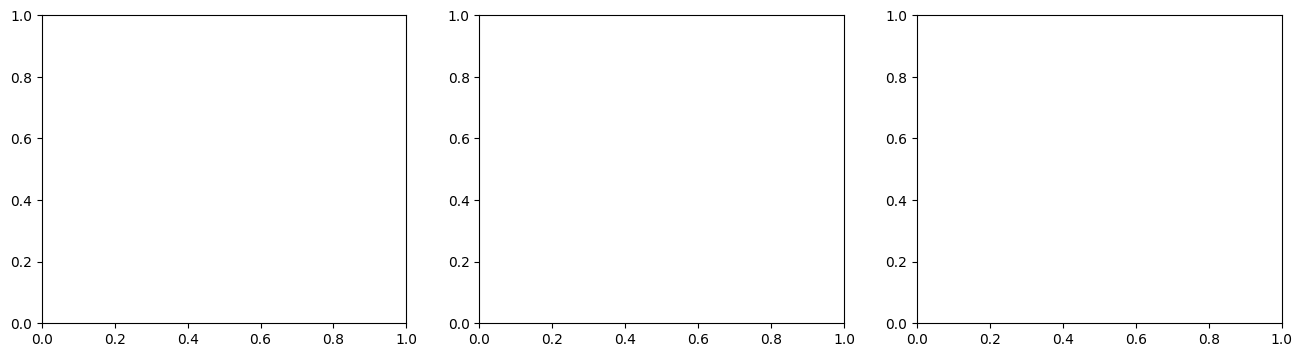

In [26]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
classes = winner_model.classes_
for ax, preds, title in zip(
    axes,
    [lr_preds, rf_preds, xgb_preds],
    ['Logistic Regression', 'Random Forest', 'XGBoost']
):
    cm = confusion_matrix(y_test, preds, labels=classes)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrices.png')

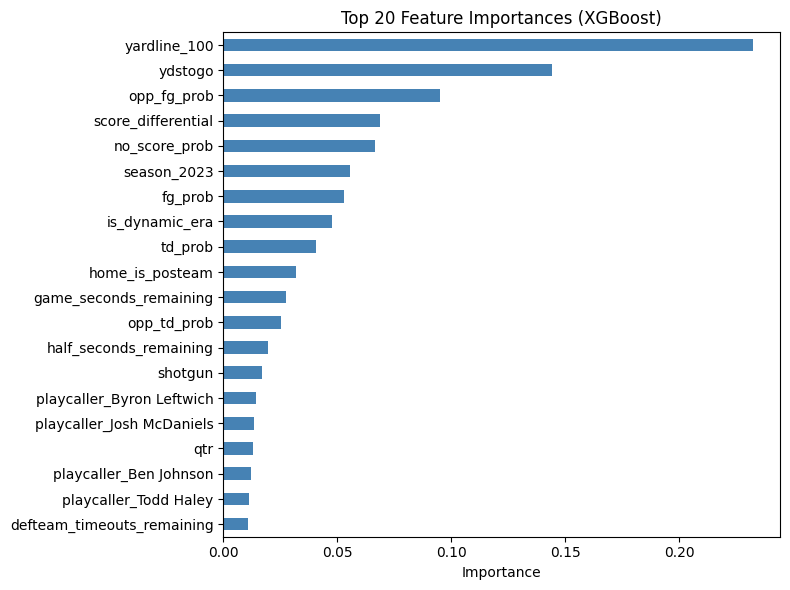

Saved: feature_importance.png


In [29]:
# Feature importance from XGBoost
xgb_model = best_xgb  # Get the underlying booster for feature importance
feat_imp = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
top_features = feat_imp.nlargest(20)

fig, ax = plt.subplots(figsize=(8, 6))
top_features.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 20 Feature Importances (XGBoost)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: feature_importance.png')

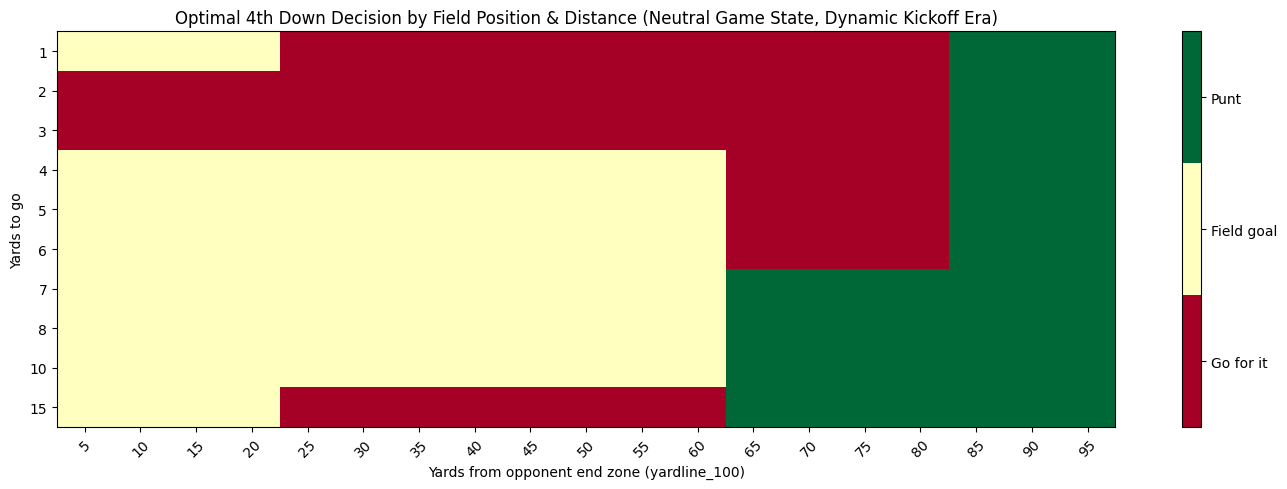

Saved: decision_heatmap.png


In [33]:
# Decision heatmap: optimal play type by field position x yards to go
# Use the XGBoost model to predict over a grid of scenarios

yardlines = np.arange(5, 100, 5)
distances  = [1, 2, 3, 4, 5, 6, 7, 8, 10, 15]

# Build a grid of 'neutral' scenarios (close game, mid-game, 1 timeout each)
rows = []
for yl in yardlines:
    for dist in distances:
        row = {f: 0 for f in all_features}
        row['yardline_100'] = yl
        row['ydstogo'] = dist
        row['score_differential'] = 0
        row['game_seconds_remaining'] = 1800
        row['half_seconds_remaining'] = 900
        row['qtr'] = 3
        row['posteam_timeouts_remaining'] = 2
        row['defteam_timeouts_remaining'] = 2
        row['goal_to_go'] = 1 if (yl <= dist) else 0
        row['is_dynamic_era'] = 1
        rows.append({'yardline_100': yl, 'ydstogo': dist, **row})

grid_df = pd.DataFrame(rows)[all_features].fillna(0)
bool_cols = grid_df.select_dtypes(include='bool').columns
grid_df[bool_cols] = grid_df[bool_cols].astype(int)

grid_preds = xgb_model.predict(grid_df)
grid_preds_labels = le.inverse_transform(grid_preds)

heatmap_data = pd.DataFrame({
    'yardline_100': [r['yardline_100'] for r in rows],
    'ydstogo': [r['ydstogo'] for r in rows],
    'optimal': grid_preds_labels
})

decision_map = {'go': 0, 'field_goal': 1, 'punt': 2}
heatmap_data['decision_num'] = heatmap_data['optimal'].map(decision_map)

pivot = heatmap_data.pivot(index='ydstogo', columns='yardline_100', values='decision_num')

fig, ax = plt.subplots(figsize=(14, 5))
cmap = plt.cm.get_cmap('RdYlGn', 3)
im = ax.imshow(pivot.values, cmap=cmap, aspect='auto', vmin=-0.5, vmax=2.5)

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f'{int(v)}' for v in pivot.columns], rotation=45)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel('Yards from opponent end zone (yardline_100)')
ax.set_ylabel('Yards to go')
ax.set_title('Optimal 4th Down Decision by Field Position & Distance (Neutral Game State, Dynamic Kickoff Era)')

cbar = plt.colorbar(im, ax=ax, ticks=[0, 1, 2])
cbar.ax.set_yticklabels(['Go for it', 'Field goal', 'Punt'])

plt.tight_layout()
plt.savefig('decision_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: decision_heatmap.png')

In [34]:
# Compare actual coach decisions vs. model recommendations on test set
results_df = df_model.loc[test_idx].copy()
results_df = results_df[mask.loc[test_idx]].copy()
results_df['model_recommendation'] = xgb_preds
results_df['followed_recommendation'] = (
    results_df['decision'] == results_df['model_recommendation']
).astype(int)

overall_agree = results_df['followed_recommendation'].mean()
print(f'Coach agreed with model recommendation: {overall_agree:.1%} of plays')

# By decision type
print('\nAgreement rate by actual coach decision:')
print(results_df.groupby('decision')['followed_recommendation'].mean().round(3))

Coach agreed with model recommendation: 62.1% of plays

Agreement rate by actual coach decision:
decision
field_goal    0.675
go            0.588
punt          0.609
Name: followed_recommendation, dtype: float64


In [35]:
# EPA cost of suboptimal decisions
# When coach diverged from recommendation, what was the EPA difference?
diverged = results_df[results_df['followed_recommendation'] == 0].copy()

# Merge in the mean EPA for the model's recommended decision in that bucket
diverged = diverged.merge(
    epa_pivot[group_cols + ['go', 'punt', 'field_goal']],
    on=group_cols, how='left'
)

def get_recommended_epa(row):
    return row.get(row['model_recommendation'], np.nan)

diverged['recommended_mean_epa'] = diverged.apply(get_recommended_epa, axis=1)
diverged['epa_cost'] = diverged['recommended_mean_epa'] - diverged['epa']

print(f'Plays where coach diverged from recommendation: {len(diverged):,}')
print(f'Mean EPA left on the table per divergent play: {diverged["epa_cost"].mean():.3f}')
print(f'Total EPA cost across test season: {diverged["epa_cost"].sum():.1f}')

Plays where coach diverged from recommendation: 1,725
Mean EPA left on the table per divergent play: 1.234
Total EPA cost across test season: 2128.9


## 8. Summary Table

In [36]:
from sklearn.metrics import accuracy_score

summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, lr_preds),
        accuracy_score(y_test, rf_preds),
        accuracy_score(y_test, xgb_preds)
    ],
    'Log Loss': [
        log_loss(y_test, lr_probs),
        log_loss(y_test, rf_probs),
        log_loss(y_test, xgb_probs)
    ]
})
summary['Accuracy'] = summary['Accuracy'].round(4)
summary['Log Loss'] = summary['Log Loss'].round(4)
print(summary.to_string(index=False))

              Model  Accuracy  Log Loss
Logistic Regression    0.6438    0.7661
      Random Forest    0.7059    0.4919
            XGBoost    0.9263    0.2482
